**Pneumonia Detection using Resnet Transfer Learning for vorhersage with LIME**

Vorhersage: NORMAL (Konfidenz: 0.55)


  0%|          | 0/1000 [00:00<?, ?it/s]

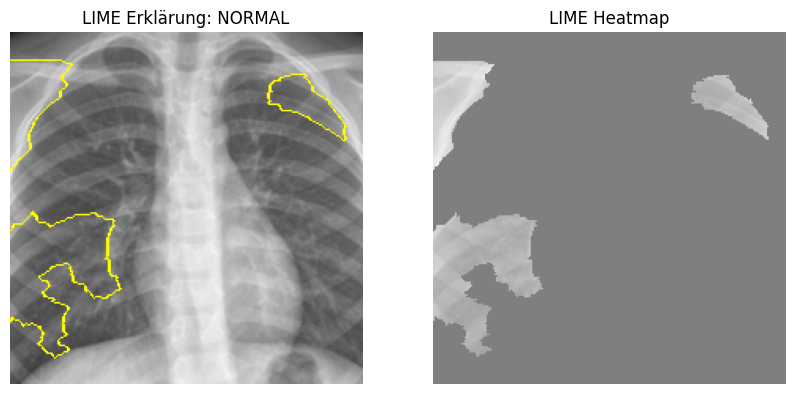

In [12]:
import torch
import torchvision.models as models
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from lime.lime_image import LimeImageExplainer
from skimage.segmentation import mark_boundaries

# -----------------------------
# Globale Variablen
# -----------------------------
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
class_names = ['NORMAL', 'PNEUMONIA']
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

inference_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

# -----------------------------
# Modell laden
# -----------------------------
def load_model(save_path: str, class_names: list):
    """Lädt das ResNet101 Modell mit angepasster Klassifikationsschicht."""
    model = models.resnet101(pretrained=False)
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_ftrs, 128),
        nn.ReLU(inplace=True),
        nn.Linear(128, len(class_names))
    ).to(device)

    model.load_state_dict(torch.load(save_path, map_location=device))
    model = model.to(device)
    model.eval()
    return model

# -----------------------------
# Vorhersage für ein Bild
# -----------------------------
def predict_image(image_path: str, model, transform, class_names: list):
    """Macht eine Vorhersage für ein einzelnes Bild."""
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image)
    input_batch = input_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_batch)

    probabilities = F.softmax(output[0], dim=0)
    _, predicted_idx = torch.max(output, 1)

    predicted_class_name = class_names[predicted_idx.item()]
    confidence = probabilities[predicted_idx.item()].item()

    return predicted_class_name, confidence, probabilities.cpu(), input_tensor.cpu()

# -----------------------------
# LIME-kompatible predict_proba
# -----------------------------
def predict_proba(images, model):
    """Wandelt NumPy-Bilder in Tensoren um und gibt Wahrscheinlichkeiten zurück (für LIME)."""
    images_tensor = torch.from_numpy(images).float().permute(0, 3, 1, 2).to(device)

    mean_t = torch.tensor(mean).to(device).view(1, 3, 1, 1)
    std_t = torch.tensor(std).to(device).view(1, 3, 1, 1)
    images_tensor = (images_tensor - mean_t) / std_t

    model.eval()
    with torch.no_grad():
        outputs = model(images_tensor)

    probabilities = F.softmax(outputs, dim=1)
    return probabilities.cpu().numpy()

# -----------------------------
# LIME Erklärung erzeugen
# -----------------------------
def explain_with_lime(image_path: str, model, class_names: list, num_samples: int = 1000):
    """Erzeugt eine LIME-Erklärung für ein Bild."""
    image = Image.open(image_path).convert('RGB')
    input_tensor = inference_transform(image)
    image_np = input_tensor.cpu().numpy().transpose((1, 2, 0))

    # Un-Normalisierung für LIME
    mean_np = np.array(mean)
    std_np = np.array(std)
    lime_image = np.clip(std_np * image_np + mean_np, 0, 1)

    explainer = LimeImageExplainer()
    explanation = explainer.explain_instance(
        image=lime_image,
        classifier_fn=lambda imgs: predict_proba(imgs, model),
        top_labels=1,
        hide_color=0,
        num_samples=num_samples
    )

    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=5,
        hide_rest=True
    )

    # Visualisierung
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(mark_boundaries(lime_image, mask))
    ax[0].set_title(f"LIME Erklärung: {class_names[explanation.top_labels[0]]}")
    ax[0].axis("off")

    ax[1].imshow(temp / 2 + 0.5)
    ax[1].set_title("LIME Heatmap")
    ax[1].axis("off")

    plt.show()

# -----------------------------
# Beispielaufruf
# -----------------------------
if __name__ == "__main__":
    save_path = "/content/drive/MyDrive/pneumonia_resnet101_best_model.pth"
    image_path = "/content/drive/MyDrive/chest_xray/test/NORMAL/IM-0001-0001.jpeg"

    model = load_model(save_path, class_names)

    pred_class, conf, probs, tensor = predict_image(image_path, model, inference_transform, class_names)
    print(f"Vorhersage: {pred_class} (Konfidenz: {conf:.2f})")

    explain_with_lime(image_path, model, class_names)
